c:\Users\ASUS\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] 系统找不到指定的文件。
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\ASUS\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\ASUS\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\ASUS\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
          

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000050 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 64
[LightGBM] [Info] Number of data points in the train set: 933, number of used features: 4
[LightGBM] [Info] Start training from score 3.647678
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

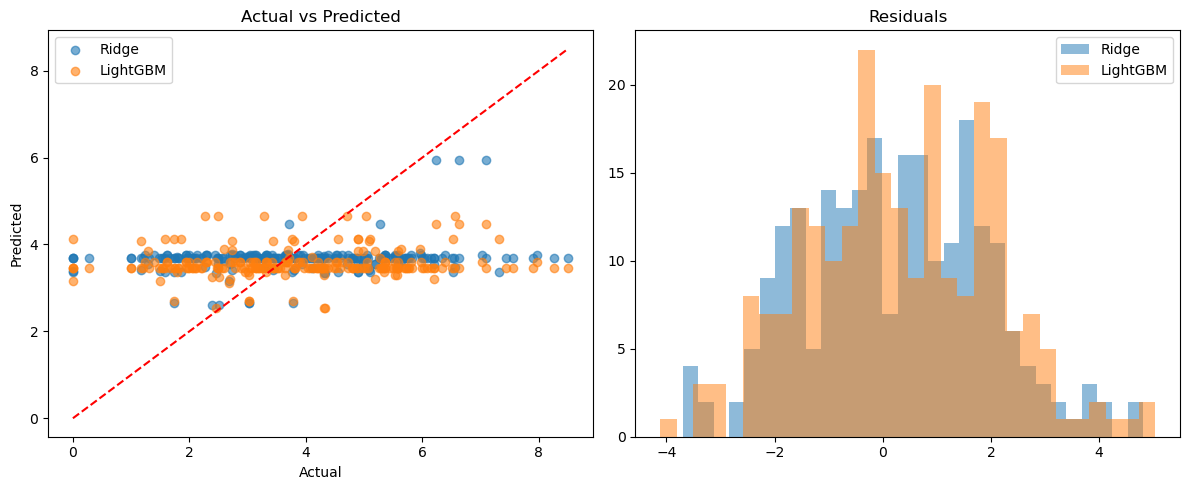

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.linear_model import Ridge
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
pre = pd.read_csv('pre_release_dataset_final_clean.csv')
post = pd.read_csv('post_release_dataset_clean_final.csv')
df = pd.merge(pre, post, on='game-name')

# Target engineering
df['log_steam_players'] = np.log1p(df['steam_current_players'])
df['log_youtube_views'] = np.log1p(df['youtube_total_views'])
df['success_score'] = 0.6 * df['log_steam_players'] + 0.4 * df['log_youtube_views']
df = df[df['success_score'] <= df['success_score'].quantile(0.99)]  # Remove top 1% outliers

# Aggressive grouping
def top_or_other(series, n=5):
    top = series.value_counts().index[:n]
    return series.apply(lambda x: x if x in top else 'Other')

df['steam_genres'] = df['steam_genres'].fillna('Unknown')
df['steam_developers'] = df['steam_developers'].fillna('Unknown')
df['steam_publishers'] = df['steam_publishers'].fillna('Unknown')

df['main_genre'] = top_or_other(df['steam_genres'], 5)
df['main_dev'] = top_or_other(df['steam_developers'], 5)
df['main_pub'] = top_or_other(df['steam_publishers'], 5)

# Count/interactions
df['n_genres'] = df['steam_genres'].apply(lambda x: len(str(x).split(';')))
df['dev_is_pub'] = (df['steam_developers'] == df['steam_publishers']).astype(int)

# Target encoding with KFold
def target_encode(train_X, train_y, test_X, col, n_splits=5):
    global_mean = train_y.mean()
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    train_encoded = pd.Series(index=train_X.index, dtype=float)
    for train_idx, val_idx in kf.split(train_X):
        means = train_y.iloc[train_idx].groupby(train_X.iloc[train_idx][col]).mean()
        train_encoded.iloc[val_idx] = train_X.iloc[val_idx][col].map(means).fillna(global_mean)
    test_encoded = test_X[col].map(train_y.groupby(train_X[col]).mean()).fillna(global_mean)
    return train_encoded, test_encoded

# Prepare features/target
features = ['main_genre', 'main_dev', 'main_pub', 'n_genres', 'dev_is_pub']
X = df[features]
y = df['success_score']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Target encode categoricals
for col in ['main_genre', 'main_dev', 'main_pub']:
    tr_enc, te_enc = target_encode(X_train, y_train, X_test, col)
    X_train[f'{col}_te'] = tr_enc
    X_test[f'{col}_te'] = te_enc

# Drop original categoricals, keep encoded
X_train_final = X_train.drop(['main_genre', 'main_dev', 'main_pub'], axis=1)
X_test_final = X_test.drop(['main_genre', 'main_dev', 'main_pub'], axis=1)

# Try Ridge regression (linear)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_final, y_train)
ridge_pred = ridge.predict(X_test_final)

# Try LightGBM
lgbm = lgb.LGBMRegressor(n_estimators=200, learning_rate=0.05, random_state=42)
lgbm.fit(X_train_final, y_train)
lgbm_pred = lgbm.predict(X_test_final)

# Evaluate
def print_metrics(name, y_true, y_pred):
    print(f"{name} MAE: {mean_absolute_error(y_true, y_pred):.4f}")
    print(f"{name} R²: {r2_score(y_true, y_pred):.4f}")

print_metrics("Ridge", y_test, ridge_pred)
print_metrics("LightGBM", y_test, lgbm_pred)

# Plot
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(y_test, ridge_pred, alpha=0.6, label='Ridge')
plt.scatter(y_test, lgbm_pred, alpha=0.6, label='LightGBM')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.legend()

plt.subplot(1,2,2)
plt.hist(y_test - ridge_pred, bins=30, alpha=0.5, label='Ridge')
plt.hist(y_test - lgbm_pred, bins=30, alpha=0.5, label='LightGBM')
plt.title('Residuals')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style for better visuals
sns.set_style('whitegrid')
plt.rc('figure', figsize=(12, 8))
plt.rc('font', size=12)

# Load the final cleaned datasets
pre_release_df = pd.read_csv('pre_release_dataset_final_clean.csv')
post_release_df = pd.read_csv('post_release_dataset_final_clean.csv')

# Merge the two dataframes on the correct column name 'game-name'
df = pd.merge(pre_release_df, post_release_df, on='game-name')

print("✅ Data loaded and merged successfully!")
print(f"�� Dataset shape: {df.shape}")
print(f"🎮 Number of unique games: {df['game-name'].nunique()}")

df.head()

✅ Data loaded and merged successfully!
�� Dataset shape: (1179, 93)
🎮 Number of unique games: 1175


,steam_appid,game-name,steam_release_date,steam_price,steam_genres,steam_categories,steam_developers,steam_publishers,steam_review_count,steam_positive_rate,...,Unnamed: 68,Unnamed: 69,Unnamed: 70,Unnamed: 71,Unnamed: 72,Unnamed: 73,Unnamed: 74,Unnamed: 75,Unnamed: 76,Unnamed: 77
0,3787220,"""Tiny bunny"" - Manga Vol. 1",16-Jun-25,$5.00,"Adventure,Indie","Single-player,Downloadable Content,Family Sharing","Saikono,Sokarev",Saikono,55,80,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2784140,100 Cats London,16-Mar-25,$0.55,"Casual,Indie","Single-player,Steam Achievements,Color Alterna...",100 Cats,100 Cats,36,70,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2784250,100 Cats Mexico,22-Sep-24,$0.49,"Casual,Indie","Single-player,Steam Achievements,Color Alterna...",100 Cats,100 Cats,48,70,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2782380,100 Cats New York,27-Aug-24,Free,"Casual,Indie,Free To Play","Single-player,Steam Achievements,Color Alterna...",100 Cats,100 Cats,2,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3245740,100 Hidden Kooky & Hiking Boots,24-Oct-24,$0.99,"Casual,Indie","Single-player,Steam Achievements,Full controll...",Roshan Nowshad,Roshan Nowshad,31,70,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
